# Weight sensitivity analysis for Pareto-front solution selection

Multi-SpaCE returns a Pareto front, while baseline methods return a single counterfactual. For tabular comparison, one Multi-SpaCE solution must be selected with scalar objective weights. This notebook checks whether method rankings stay stable when those weights vary.

Main sweeps keep adversarial or desired-class probability weight fixed at `0.1`, because Multi-SpaCE already enforces validity independently. Sweeps therefore focus on sparsity, contiguity or number of subsequences, and plausibility.

Because ranks can stay nearly unchanged even when raw metric values move, each sweep also reports direct Multi-SpaCE metric evolution and line plots across weight profiles.


In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display


def find_repo_root(start_path=None):
    start_path = Path.cwd() if start_path is None else Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'experiments' / 'evaluation' / 'evaluation_utils.py').exists():
            return candidate
    raise FileNotFoundError('Could not locate repository root from current working directory.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)
print(f'Repository root: {REPO_ROOT}')

from experiments.evaluation.evaluation_utils import calculate_metrics_for_dataset, load_dataset_for_eval


Repository root: D:\Users\mrefoyo\Proyectos\Sub-SpaCE_plus


## Settings and objective-order check


In [11]:
DEFAULT_WEIGHTS = np.array([0.1, 0.3, 0.4, 0.2], dtype=float)
BALANCED_PROFILE = np.array([0.25, 0.25, 0.25, 0.25], dtype=float)

MODEL_TO_EXPLAIN = 'inceptiontime_noscaling'
SCALING = 'none'
OSC_NAMES = {'AE': 'ae_basic_train', 'IF': 'if_basic_train', 'LOF': 'lof_basic_train'}
MULTISPACE_DIR = 'ec57e0a613241455487f3f40483cd34095c81bf7'
MULTISPACE_NAME = 'Multi-SpaCE'

MULTIVARIATE_DATASETS = [
    "BasicMotions", "NATOPS", "UWaveGestureLibrary",
    'ArticularyWordRecognition', 'Cricket', 'Epilepsy', 
    'PenDigits', 'PEMS-SF', 'RacketSports', 'SelfRegulationSCP1'
]

UNIVARIATE_DATASETS = [
    'ECG200',
]

MULTIVARIATE_METHODS = {
    'abcf_gpu': 'AB-CF',
    'comte_gpu': 'COMTE',
    'discox_gpu': 'DiscoX',
    'mcels': 'M-CELS',
    MULTISPACE_DIR: MULTISPACE_NAME,
}

UNIVARIATE_METHODS = {
    'ng_gpu': 'NG',
    'glacier_gpu': 'Glacier(AE)',
    'glacier_NoAE_gpu': 'Glacier',
    'abcf_gpu': 'AB-CF',
    'discox_gpu': 'DiscoX',
    'mcels': 'M-CELS',
    MULTISPACE_DIR: MULTISPACE_NAME,
}

MULTISPACE_METHOD = {MULTISPACE_DIR: MULTISPACE_NAME}

print('Objective order confirmed from existing code:')
print('[desired-class probability, sparsity, contiguity/subsequences, plausibility]')
print('Scalarized fitness picks largest weighted sum.')
print('Invalid candidates penalized inside fitness_function_mo by subtracting 100 from every objective.')


Objective order confirmed from existing code:
[desired-class probability, sparsity, contiguity/subsequences, plausibility]
Scalarized fitness picks largest weighted sum.
Invalid candidates penalized inside fitness_function_mo by subtracting 100 from every objective.


## Weight grids


In [12]:
def _finalize_weight_grid(records, sweep_name, target_column, target_default):
    weights_df = pd.DataFrame.from_records(records)
    weights_df['weights'] = weights_df[['w_adv', 'w_sparsity', 'w_contiguity', 'w_plausibility']].values.tolist()
    weights_df['profile'] = [f'{sweep_name}_{value:.1f}' for value in weights_df[target_column]]
    weights_df = weights_df[['profile', 'sweep', 'w_adv', 'w_sparsity', 'w_contiguity', 'w_plausibility', 'weights']]
    for weights in weights_df['weights']:
        weights_arr = np.array(weights, dtype=float)
        assert np.isclose(weights_arr.sum(), 1.0)
        assert (weights_arr >= 0).all()
    assert np.allclose(weights_df['w_adv'].values, 0.1)
    assert np.isclose(weights_df[target_column].values, target_default).any()
    return weights_df


def make_sparsity_sweep():
    records = []
    for s in np.round(np.arange(0.1, 0.8, 0.1), 1):
        records.append({
            'sweep': 'sparsity',
            'w_adv': 0.1,
            'w_sparsity': float(s),
            'w_contiguity': float((0.9 - s) * 0.4 / (0.4 + 0.2)),
            'w_plausibility': float((0.9 - s) * 0.2 / (0.4 + 0.2)),
        })
    return _finalize_weight_grid(records, 'sparsity', 'w_sparsity', 0.3)


def make_contiguity_sweep():
    records = []
    for c in np.round(np.arange(0.1, 0.8, 0.1), 1):
        records.append({
            'sweep': 'contiguity',
            'w_adv': 0.1,
            'w_sparsity': float((0.9 - c) * 0.3 / (0.3 + 0.2)),
            'w_contiguity': float(c),
            'w_plausibility': float((0.9 - c) * 0.2 / (0.3 + 0.2)),
        })
    return _finalize_weight_grid(records, 'contiguity', 'w_contiguity', 0.4)


def make_plausibility_sweep():
    records = []
    for p in np.round(np.arange(0.1, 0.8, 0.1), 1):
        records.append({
            'sweep': 'plausibility',
            'w_adv': 0.1,
            'w_sparsity': float((0.9 - p) * 0.3 / (0.3 + 0.4)),
            'w_contiguity': float((0.9 - p) * 0.4 / (0.3 + 0.4)),
            'w_plausibility': float(p),
        })
    return _finalize_weight_grid(records, 'plausibility', 'w_plausibility', 0.2)


sparsity_weights_df = make_sparsity_sweep()
contiguity_weights_df = make_contiguity_sweep()
plausibility_weights_df = make_plausibility_sweep()

print('Sparsity sweep')
display(sparsity_weights_df)
print('Contiguity sweep')
display(contiguity_weights_df)
print('Plausibility sweep')
display(plausibility_weights_df)
print(f'Balanced profile: {BALANCED_PROFILE.tolist()}')


Sparsity sweep


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,weights
0,sparsity_0.1,sparsity,0.1,0.1,0.533333,0.266667,"[0.1, 0.1, 0.5333333333333333, 0.2666666666666..."
1,sparsity_0.2,sparsity,0.1,0.2,0.466667,0.233333,"[0.1, 0.2, 0.46666666666666656, 0.233333333333..."
2,sparsity_0.3,sparsity,0.1,0.3,0.400000,0.200000,"[0.1, 0.3, 0.4, 0.2]"
3,sparsity_0.4,sparsity,0.1,0.4,0.333333,0.166667,"[0.1, 0.4, 0.3333333333333333, 0.1666666666666..."
4,sparsity_0.5,sparsity,0.1,0.5,0.266667,0.133333,"[0.1, 0.5, 0.26666666666666666, 0.133333333333..."
5,sparsity_0.6,sparsity,0.1,0.6,0.200000,0.100000,"[0.1, 0.6, 0.2, 0.1]"
6,sparsity_0.7,sparsity,0.1,0.7,0.133333,0.066667,"[0.1, 0.7, 0.13333333333333336, 0.066666666666..."


Contiguity sweep


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,weights
0,contiguity_0.1,contiguity,0.1,0.48,0.1,0.32,"[0.1, 0.48, 0.1, 0.32000000000000006]"
1,contiguity_0.2,contiguity,0.1,0.42,0.2,0.28,"[0.1, 0.42, 0.2, 0.27999999999999997]"
2,contiguity_0.3,contiguity,0.1,0.36,0.3,0.24,"[0.1, 0.36000000000000004, 0.3, 0.240000000000..."
3,contiguity_0.4,contiguity,0.1,0.30,0.4,0.20,"[0.1, 0.3, 0.4, 0.2]"
4,contiguity_0.5,contiguity,0.1,0.24,0.5,0.16,"[0.1, 0.24, 0.5, 0.16000000000000003]"
5,contiguity_0.6,contiguity,0.1,0.18,0.6,0.12,"[0.1, 0.18000000000000002, 0.6, 0.120000000000..."
6,contiguity_0.7,contiguity,0.1,0.12,0.7,0.08,"[0.1, 0.12000000000000004, 0.7, 0.080000000000..."


Plausibility sweep


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,weights
0,plausibility_0.1,plausibility,0.1,0.342857,0.457143,0.1,"[0.1, 0.34285714285714286, 0.45714285714285724..."
1,plausibility_0.2,plausibility,0.1,0.300000,0.400000,0.2,"[0.1, 0.3, 0.39999999999999997, 0.2]"
2,plausibility_0.3,plausibility,0.1,0.257143,0.342857,0.3,"[0.1, 0.2571428571428572, 0.34285714285714297,..."
3,plausibility_0.4,plausibility,0.1,0.214286,0.285714,0.4,"[0.1, 0.2142857142857143, 0.28571428571428575,..."
4,plausibility_0.5,plausibility,0.1,0.171429,0.228571,0.5,"[0.1, 0.17142857142857143, 0.22857142857142862..."
5,plausibility_0.6,plausibility,0.1,0.128571,0.171429,0.6,"[0.1, 0.1285714285714286, 0.17142857142857149,..."
6,plausibility_0.7,plausibility,0.1,0.085714,0.114286,0.7,"[0.1, 0.08571428571428574, 0.11428571428571434..."


Balanced profile: [0.25, 0.25, 0.25, 0.25]


## Evaluation helpers


In [13]:
HIGHER_BETTER = {'valid', 'proba'}
LOWER_BETTER_ORDER = [
    'L1',
    'L2',
    'sparsity',
    'nchanges',
    'subsequences',
    'subsequences %',
    'sparsity_nos',
    'AE_OS',
    'IF_OS',
    'LOF_OS',
    'AE_IOS',
    'IF_IOS',
    'LOF_IOS',
    'times',
]
DISPLAY_METRICS = [
    'valid',
    'proba',
    'L2',
    'sparsity',
    'subsequences',
    'subsequences %',
    'sparsity_nos',
    'AE_OS',
    'IF_OS',
    'LOF_OS',
    'AE_IOS',
    'IF_IOS',
    'LOF_IOS',
    'times',
]
NORMALIZED_SUBSEQUENCE_CANDIDATES = [
    'subsequences %',
    'normalized_subsequences',
    'normalized subsequences',
    'NoS [%]',
]
PLOT_METRICS = [
    'valid',
    'proba',
    'L2',
    'sparsity',
    'subsequences',
    'subsequences %',
    'sparsity_nos',
    'AE_OS',
    'IF_OS',
    'LOF_OS',
    'times',
]
SWEEP_X_COLUMN = {
    'sparsity': 'w_sparsity',
    'contiguity': 'w_contiguity',
    'plausibility': 'w_plausibility',
}


def get_normalized_subsequence_column(columns):
    for candidate in NORMALIZED_SUBSEQUENCE_CANDIDATES:
        if candidate in columns:
            return candidate
    return None


def prepare_contexts(datasets, setting_name):
    contexts = {}
    for dataset in tqdm(datasets, desc=f'Loading {setting_name} datasets'):
        data_tuple, original_classes, model_wrapper, outlier_calculators, possible_nuns, desired_classes = load_dataset_for_eval(
            dataset,
            MODEL_TO_EXPLAIN,
            OSC_NAMES,
            scaling=SCALING,
        )
        contexts[dataset] = {
            'data_tuple': data_tuple,
            'original_classes': original_classes,
            'model_wrapper': model_wrapper,
            'outlier_calculators': outlier_calculators,
            'possible_nuns': possible_nuns,
            'desired_classes': desired_classes,
        }
    return contexts


def evaluate_setting(contexts, datasets, methods, mo_weights, setting_name):
    raw_frames = []
    for dataset in tqdm(datasets, desc=f'Evaluating {setting_name}'):
        ctx = contexts[dataset]
        _, results_df, _, common_test_indexes = calculate_metrics_for_dataset(
            dataset,
            methods,
            MODEL_TO_EXPLAIN,
            ctx['data_tuple'],
            ctx['original_classes'],
            ctx['model_wrapper'],
            ctx['outlier_calculators'],
            ctx['possible_nuns'],
            mo_weights=np.array(mo_weights, dtype=float),
        )
        results_df = results_df.copy()
        results_df['dataset'] = dataset
        results_df['setting'] = setting_name
        results_df['n_common_test_indexes'] = len(common_test_indexes)
        raw_frames.append(results_df)
    return pd.concat(raw_frames, ignore_index=True)


def aggregate_method_dataset_metrics(results_df):
    metric_candidates = [
        'nchanges',
        'sparsity',
        'L1',
        'L2',
        'proba',
        'valid',
        'AE_OS',
        'IF_OS',
        'LOF_OS',
        'AE_IOS',
        'IF_IOS',
        'LOF_IOS',
        'subsequences',
        'subsequences %',
        'times',
    ]
    present_metrics = [column for column in metric_candidates if column in results_df.columns]
    dataset_means = results_df.groupby(['dataset', 'method'], as_index=False)[present_metrics].mean(numeric_only=True)
    normalized_subsequence_column = get_normalized_subsequence_column(dataset_means.columns)
    if 'sparsity' in dataset_means.columns and normalized_subsequence_column is not None:
        dataset_means['sparsity_nos'] = (
            dataset_means['sparsity'] + dataset_means[normalized_subsequence_column]
        ) / 2.0
    return dataset_means


def compute_average_ranks(results_df):
    dataset_means = aggregate_method_dataset_metrics(results_df)
    metrics = [metric for metric in ['valid', 'proba', *LOWER_BETTER_ORDER] if metric in dataset_means.columns]
    ranked_dataset_means = dataset_means.copy()
    for metric in metrics:
        ascending = metric not in HIGHER_BETTER
        ranked_dataset_means[f'{metric}_rank'] = ranked_dataset_means.groupby('dataset')[metric].rank(
            ascending=ascending,
            method='min',
        )
    rank_columns = [f'{metric}_rank' for metric in metrics]
    average_ranks = ranked_dataset_means.groupby('method', as_index=False)[rank_columns].mean(numeric_only=True)
    average_ranks = average_ranks.rename(columns={column: column.replace('_rank', '') for column in rank_columns})
    return dataset_means, ranked_dataset_means, average_ranks


def extract_per_dataset_rank_table(results_df, method_filter=None):
    _, ranked_dataset_means, _ = compute_average_ranks(results_df)
    rank_columns = [column for column in ranked_dataset_means.columns if column.endswith('_rank')]
    columns = ['dataset', 'method', *rank_columns]
    table = ranked_dataset_means.loc[:, columns].copy()
    if method_filter is not None:
        if isinstance(method_filter, str):
            method_filter = [method_filter]
        table = table.loc[table['method'].isin(method_filter)].copy()
    return table.sort_values(['dataset', 'method']).reset_index(drop=True)


def display_per_dataset_rank_check(results_df, title, method_filter=None):
    print(title)
    display(extract_per_dataset_rank_table(results_df, method_filter=method_filter))


def make_rank_display_table(average_ranks, methods_order=None):
    display_columns = ['method', *[metric for metric in DISPLAY_METRICS if metric in average_ranks.columns]]
    table = average_ranks.loc[:, display_columns].copy()
    if methods_order is not None:
        method_position = {method_name: index for index, method_name in enumerate(methods_order)}
        table['_ord'] = table['method'].map(method_position)
        table = table.sort_values(['_ord', 'method']).drop(columns='_ord')
    return table.reset_index(drop=True)


def extract_multispace_rank_rows(ranks_by_profile):
    subset = ranks_by_profile.loc[ranks_by_profile['method'] == MULTISPACE_NAME].copy()
    columns = [
        'profile',
        'sweep',
        'w_adv',
        'w_sparsity',
        'w_contiguity',
        'w_plausibility',
        *[metric for metric in DISPLAY_METRICS if metric in subset.columns],
    ]
    return subset.loc[:, columns].reset_index(drop=True)


def summarize_counts(results_df, by_columns):
    return results_df.groupby(list(by_columns), dropna=False).size().reset_index(name='n_instances')


def evaluate_multispace_grid(
    weights_df,
    default_results,
    datasets,
    multispace_method_config,
    model_to_explain,
    setting_name,
    contexts,
):
    baseline_rows = default_results.loc[default_results['method'] != MULTISPACE_NAME].copy()
    combined_results = []
    combined_ranks = []
    for row in weights_df.itertuples(index=False):
        multispace_results = evaluate_setting(
            contexts,
            datasets,
            multispace_method_config,
            row.weights,
            setting_name=setting_name,
        )
        profile_meta = {
            'profile': row.profile,
            'sweep': row.sweep,
            'w_adv': row.w_adv,
            'w_sparsity': row.w_sparsity,
            'w_contiguity': row.w_contiguity,
            'w_plausibility': row.w_plausibility,
            'setting': setting_name,
        }
        baseline_with_meta = baseline_rows.assign(**profile_meta)
        baseline_with_meta['weights'] = [list(row.weights)] * len(baseline_with_meta)
        multispace_with_meta = multispace_results.assign(**profile_meta)
        multispace_with_meta['weights'] = [list(row.weights)] * len(multispace_with_meta)
        combined = pd.concat([baseline_with_meta, multispace_with_meta], ignore_index=True)
        _, _, average_ranks = compute_average_ranks(combined)
        average_ranks = average_ranks.assign(**profile_meta)
        average_ranks['weights'] = [list(row.weights)] * len(average_ranks)
        combined_results.append(combined)
        combined_ranks.append(average_ranks)
    return pd.concat(combined_results, ignore_index=True), pd.concat(combined_ranks, ignore_index=True)


def compute_profile_metric_summary(results_by_profile):
    metadata_columns = [
        'setting',
        'sweep',
        'profile',
        'w_adv',
        'w_sparsity',
        'w_contiguity',
        'w_plausibility',
        'weights_label',
    ]
    multispace_results = results_by_profile.loc[results_by_profile['method'] == MULTISPACE_NAME].copy()
    dataset_metric_frames = []
    for profile, profile_df in multispace_results.groupby('profile', sort=False):
        dataset_means = aggregate_method_dataset_metrics(profile_df)
        dataset_means = dataset_means.loc[dataset_means['method'] == MULTISPACE_NAME].copy()
        meta_values = {
            'setting': profile_df['setting'].iloc[0],
            'sweep': profile_df['sweep'].iloc[0],
            'profile': profile_df['profile'].iloc[0],
            'w_adv': profile_df['w_adv'].iloc[0],
            'w_sparsity': profile_df['w_sparsity'].iloc[0],
            'w_contiguity': profile_df['w_contiguity'].iloc[0],
            'w_plausibility': profile_df['w_plausibility'].iloc[0],
            'weights_label': str(list(profile_df['weights'].iloc[0])),
        }
        for key, value in meta_values.items():
            dataset_means[key] = value
        dataset_metric_frames.append(dataset_means)
    dataset_metric_summary = pd.concat(dataset_metric_frames, ignore_index=True)
    numeric_metric_columns = [metric for metric in DISPLAY_METRICS if metric in dataset_metric_summary.columns]
    profile_metric_summary = dataset_metric_summary.groupby(metadata_columns, as_index=False)[numeric_metric_columns].mean(numeric_only=True)
    profile_metric_summary['n_datasets'] = dataset_metric_summary.groupby(metadata_columns)['dataset'].nunique().values
    return dataset_metric_summary, profile_metric_summary


def extract_multispace_metric_rows(profile_metric_summary):
    columns = [
        'profile',
        'sweep',
        'w_adv',
        'w_sparsity',
        'w_contiguity',
        'w_plausibility',
        *[metric for metric in DISPLAY_METRICS if metric in profile_metric_summary.columns],
    ]
    return profile_metric_summary.loc[:, columns].reset_index(drop=True)


def plot_metric_evolution(profile_metric_summary, title_prefix):
    if profile_metric_summary.empty:
        print('No profile metric summary available.')
        return
    sweep_name = profile_metric_summary['sweep'].iloc[0]
    x_column = SWEEP_X_COLUMN.get(sweep_name)
    if x_column is None:
        print(f'No sweep x-axis mapping defined for {sweep_name}.')
        return
    plot_df = profile_metric_summary.sort_values(x_column).copy()
    metrics_to_plot = [metric for metric in PLOT_METRICS if metric in plot_df.columns]
    if not metrics_to_plot:
        print('No metrics available for plotting.')
        return
    ncols = 3
    nrows = int(np.ceil(len(metrics_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)
    x_values = plot_df[x_column].values
    for ax, metric in zip(axes.flatten(), metrics_to_plot):
        ax.plot(x_values, plot_df[metric].values, marker='o', linewidth=2)
        ax.set_title(metric)
        ax.set_xlabel(x_column)
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.3)
        if metric in HIGHER_BETTER:
            best_idx = int(np.nanargmax(plot_df[metric].values)) if np.isfinite(plot_df[metric].values).any() else None
        else:
            best_idx = int(np.nanargmin(plot_df[metric].values)) if np.isfinite(plot_df[metric].values).any() else None
        if best_idx is not None:
            ax.axvline(x_values[best_idx], color='tab:red', linestyle='--', alpha=0.4)
    for ax in axes.flatten()[len(metrics_to_plot):]:
        ax.axis('off')
    fig.suptitle(title_prefix, fontsize=14)
    fig.tight_layout()
    plt.show()


def build_stability_summary(default_ranks, sweep_ranks, setting_name):
    default_row = default_ranks.loc[default_ranks['method'] == MULTISPACE_NAME]
    sweep_rows = sweep_ranks.loc[sweep_ranks['method'] == MULTISPACE_NAME]
    metrics = [metric for metric in DISPLAY_METRICS if metric in default_row.columns and metric in sweep_rows.columns]
    records = []
    for metric in metrics:
        metric_values = sweep_rows[metric].dropna()
        if metric_values.empty:
            continue
        records.append({
            'setting': setting_name,
            'metric': metric,
            'default_rank': float(default_row[metric].iloc[0]),
            'min_rank': float(metric_values.min()),
            'max_rank': float(metric_values.max()),
            'mean_rank': float(metric_values.mean()),
            'std_rank': float(metric_values.std(ddof=0)),
        })
    return pd.DataFrame.from_records(records)


def add_default_profile_metadata(results_df, setting_name):
    results_df = results_df.copy()
    results_df['profile'] = 'default'
    results_df['sweep'] = 'default'
    results_df['w_adv'] = DEFAULT_WEIGHTS[0]
    results_df['w_sparsity'] = DEFAULT_WEIGHTS[1]
    results_df['w_contiguity'] = DEFAULT_WEIGHTS[2]
    results_df['w_plausibility'] = DEFAULT_WEIGHTS[3]
    results_df['weights'] = [DEFAULT_WEIGHTS.tolist()] * len(results_df)
    results_df['setting'] = setting_name
    return results_df


## Default comparison: baselines + original Multi-SpaCE weights


In [14]:
multivariate_contexts = prepare_contexts(MULTIVARIATE_DATASETS, 'multivariate')
univariate_contexts = prepare_contexts(UNIVARIATE_DATASETS, 'univariate')

default_results_multi = evaluate_setting(
    multivariate_contexts,
    MULTIVARIATE_DATASETS,
    MULTIVARIATE_METHODS,
    DEFAULT_WEIGHTS,
    setting_name='multivariate_default',
)
_, _, default_ranks_multi = compute_average_ranks(default_results_multi)
default_counts_multi = summarize_counts(default_results_multi, ['dataset', 'method'])

                                                  
"""default_results_uni = evaluate_setting(
    univariate_contexts,
    UNIVARIATE_DATASETS,
    UNIVARIATE_METHODS,
    DEFAULT_WEIGHTS,
    setting_name='univariate_default',
)
_, _, default_ranks_uni = compute_average_ranks(default_results_uni)
default_counts_uni = summarize_counts(default_results_uni, ['dataset', 'method'])
"""



Loading multivariate datasets:   0%|          | 0/10 [00:00<?, ?it/s]

Loading univariate datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Evaluating multivariate_default:   0%|          | 0/10 [00:00<?, ?it/s]

abcf_gpu



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:01<00:00, 29.52it/s]


...


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:42<00:00,  2.34it/s]


mcels



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:21<00:00,  4.59it/s]


Common test indexes are 20: [46, 47, 65, 78, 100, 111, 124, 136, 169, 172, 176, 197, 213, 222, 224, 234, 239, 241, 245, 277]


"default_results_uni = evaluate_setting(\n    univariate_contexts,\n    UNIVARIATE_DATASETS,\n    UNIVARIATE_METHODS,\n    DEFAULT_WEIGHTS,\n    setting_name='univariate_default',\n)\n_, _, default_ranks_uni = compute_average_ranks(default_results_uni)\ndefault_counts_uni = summarize_counts(default_results_uni, ['dataset', 'method'])\n"

In [15]:
print('Multivariate default average ranks')
display(make_rank_display_table(default_ranks_multi, list(MULTIVARIATE_METHODS.values())))

Multivariate default average ranks


,method,valid,proba,L2,sparsity,subsequences,subsequences %,sparsity_nos,AE_OS,IF_OS,LOF_OS,AE_IOS,IF_IOS,LOF_IOS,times
0,AB-CF,2.0,2.2,4.800000,4.900000,3.500000,3.500000,4.9,1.600000,3.200000,3.100000,2.400000,4.4,4.000000,1.0
1,COMTE,1.2,3.9,3.100000,3.100000,4.700000,4.700000,3.6,4.300000,3.500000,3.700000,4.200000,3.4,3.200000,4.3
2,DiscoX,4.8,5.0,2.666667,2.444444,1.222222,1.222222,2.0,3.222222,2.555556,2.888889,3.333333,3.0,3.444444,4.5
3,M-CELS,4.2,1.6,1.600000,1.100000,3.000000,3.000000,1.4,3.800000,3.000000,2.600000,3.400000,2.3,2.500000,2.9
4,Multi-SpaCE,1.0,2.3,2.600000,3.200000,2.200000,2.200000,2.8,1.900000,2.500000,2.500000,1.500000,1.7,1.700000,2.3


In [16]:
display_per_dataset_rank_check(
    default_results_multi,
    'Optional check: multivariate per-dataset ranks (default comparison)',
)

Optional check: multivariate per-dataset ranks (default comparison)


,dataset,method,valid_rank,proba_rank,L1_rank,L2_rank,sparsity_rank,nchanges_rank,subsequences_rank,subsequences %_rank,sparsity_nos_rank,AE_OS_rank,IF_OS_rank,LOF_OS_rank,AE_IOS_rank,IF_IOS_rank,LOF_IOS_rank,times_rank
0,ArticularyWordRecognition,AB-CF,3.0,1.0,5.0,5.0,5.0,5.0,4.0,4.0,5.0,3.0,5.0,5.0,4.0,5.0,5.0,1.0
1,ArticularyWordRecognition,COMTE,1.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,4.0,5.0,4.0,4.0,5.0,4.0,4.0,4.0
2,ArticularyWordRecognition,DiscoX,5.0,5.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,5.0
3,ArticularyWordRecognition,M-CELS,4.0,2.0,2.0,2.0,1.0,1.0,3.0,3.0,2.0,4.0,2.0,2.0,3.0,2.0,2.0,3.0
4,ArticularyWordRecognition,Multi-SpaCE,1.0,3.0,3.0,3.0,3.0,3.0,2.0,2.0,3.0,1.0,3.0,3.0,2.0,3.0,3.0,2.0
5,BasicMotions,AB-CF,3.0,3.0,5.0,5.0,5.0,5.0,4.0,4.0,5.0,2.0,3.0,3.0,2.0,3.0,4.0,1.0
6,BasicMotions,COMTE,1.0,4.0,3.0,4.0,3.0,3.0,5.0,5.0,4.0,4.0,4.0,4.0,5.0,5.0,2.0,4.0
7,BasicMotions,DiscoX,5.0,5.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0,3.0,2.0,2.0,3.0,4.0,5.0,5.0
8,BasicMotions,M-CELS,4.0,1.0,2.0,2.0,1.0,1.0,3.0,3.0,1.0,5.0,5.0,5.0,4.0,2.0,3.0,3.0
9,BasicMotions,Multi-SpaCE,1.0,2.0,4.0,3.0,4.0,4.0,2.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0


In [27]:
print('Univariate default average ranks')
display(make_rank_display_table(default_ranks_uni, list(UNIVARIATE_METHODS.values())))

Univariate default average ranks


NameError: name 'default_ranks_uni' is not defined

In [ ]:

display_per_dataset_rank_check(
    default_results_uni,
    'Optional check: univariate per-dataset ranks (default comparison)',
)


## Sparsity-weight sweep


In [30]:
sparsity_results_multi, sparsity_ranks_multi = evaluate_multispace_grid(
    sparsity_weights_df,
    default_results_multi,
    MULTIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'multivariate',
    multivariate_contexts,
)
sparsity_dataset_metrics_multi, sparsity_profile_metrics_multi = compute_profile_metric_summary(sparsity_results_multi)


Evaluating multivariate:   0%|          | 0/3 [00:00<?, ?it/s]

ec57e0a613241455487f3f40483cd34095c81bf7



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:08<00:00,  4.61it/s]


Common test indexes are 40: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:25<00:00,  3.94it/s]


...

Common test indexes are 40: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 16.96it/s]


Common test indexes are 100: [0, 1, 2, 5, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 26, 29, 30, 31, 35, 36, 37, 38, 40, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 57, 58, 59, 61, 62, 64, 66, 69, 72, 76, 77, 78, 79, 81, 83, 84, 88, 89, 91, 92, 93, 95, 99, 101, 102, 103, 104, 108, 109, 111, 112, 113, 114, 116, 117, 122, 124, 125, 126, 136, 138, 140, 141, 144, 148, 150, 151, 152, 154, 155, 156, 158, 160, 163, 164, 165, 168, 169, 170, 171, 173, 175, 177, 178, 179]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:06<00:00, 15.13it/s]


Common test indexes are 100: [3, 13, 14, 15, 19, 22, 23, 25, 29, 31, 32, 44, 47, 51, 54, 61, 64, 65, 70, 72, 76, 79, 82, 84, 88, 90, 100, 104, 105, 108, 109, 111, 113, 114, 115, 119, 121, 124, 125, 126, 127, 128, 131, 135, 136, 139, 147, 152, 154, 155, 157, 158, 161, 162, 165, 169, 172, 175, 177, 178, 185, 197, 201, 202, 203, 205, 211, 213, 215, 218, 219, 220, 224, 225, 226, 237, 238, 239, 240, 241, 243, 245, 255, 261, 262, 265, 266, 268, 273, 282, 284, 291, 292, 293, 299, 300, 302, 303, 314, 318]


In [31]:
print('Multivariate sparsity sweep: average ranks')
display(extract_multispace_rank_rows(sparsity_ranks_multi))


Multivariate sparsity sweep: average ranks


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,valid,proba,L2,sparsity,subsequences,subsequences %,sparsity_nos,AE_OS,IF_OS,LOF_OS,AE_IOS,IF_IOS,LOF_IOS,times
0,sparsity_0.1,sparsity,0.1,0.1,0.533333,0.266667,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.000000,2.333333,1.000000,1.333333,2.0,2.0
1,sparsity_0.2,sparsity,0.1,0.2,0.466667,0.233333,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.000000,2.333333,1.000000,1.333333,2.0,2.0
2,sparsity_0.3,sparsity,0.1,0.3,0.400000,0.200000,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.000000,1.666667,2.0,2.0
3,sparsity_0.4,sparsity,0.1,0.4,0.333333,0.166667,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.000000,2.333333,1.333333,1.333333,2.0,2.0
4,sparsity_0.5,sparsity,0.1,0.5,0.266667,0.133333,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.000000,2.333333,1.333333,1.333333,2.0,2.0
5,sparsity_0.6,sparsity,0.1,0.6,0.200000,0.100000,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.333333,1.333333,2.0,2.0
6,sparsity_0.7,sparsity,0.1,0.7,0.133333,0.066667,1.0,2.333333,2.666667,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.333333,1.333333,2.0,2.0


In [32]:
print('Multivariate sparsity sweep: direct metric values')
display(extract_multispace_metric_rows(sparsity_profile_metrics_multi))


Multivariate sparsity sweep: direct metric values


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,valid,proba,L2,sparsity,subsequences,subsequences %,sparsity_nos,AE_OS,IF_OS,LOF_OS,AE_IOS,IF_IOS,LOF_IOS,times
0,sparsity_0.1,sparsity,0.1,0.1,0.533333,0.266667,1.0,0.769693,31.207854,0.185973,7.240000,0.015837,0.100905,0.499184,0.327473,0.215628,0.051798,0.022934,0.023202,4.269282
1,sparsity_0.2,sparsity,0.1,0.2,0.466667,0.233333,1.0,0.746554,30.692377,0.169670,7.018333,0.015385,0.092527,0.508949,0.333876,0.218905,0.056097,0.023037,0.023172,4.269282
2,sparsity_0.3,sparsity,0.1,0.3,0.400000,0.200000,1.0,0.730093,30.343981,0.159359,6.915000,0.015225,0.087292,0.517577,0.338203,0.223342,0.061307,0.023368,0.025104,4.269282
3,sparsity_0.4,sparsity,0.1,0.4,0.333333,0.166667,1.0,0.715332,30.051085,0.150521,7.006667,0.015691,0.083106,0.525769,0.338804,0.224888,0.068220,0.022221,0.024191,4.269282
4,sparsity_0.5,sparsity,0.1,0.5,0.266667,0.133333,1.0,0.709814,29.957047,0.147232,6.986667,0.015681,0.081457,0.530966,0.340087,0.225244,0.072978,0.022254,0.024069,4.269282
5,sparsity_0.6,sparsity,0.1,0.6,0.200000,0.100000,1.0,0.698531,29.837159,0.144308,7.016667,0.015828,0.080068,0.535336,0.342561,0.225935,0.076653,0.022329,0.023534,4.269282
6,sparsity_0.7,sparsity,0.1,0.7,0.133333,0.066667,1.0,0.686450,29.681367,0.141297,7.128333,0.016088,0.078692,0.541075,0.344190,0.227950,0.081476,0.022514,0.023950,4.269282


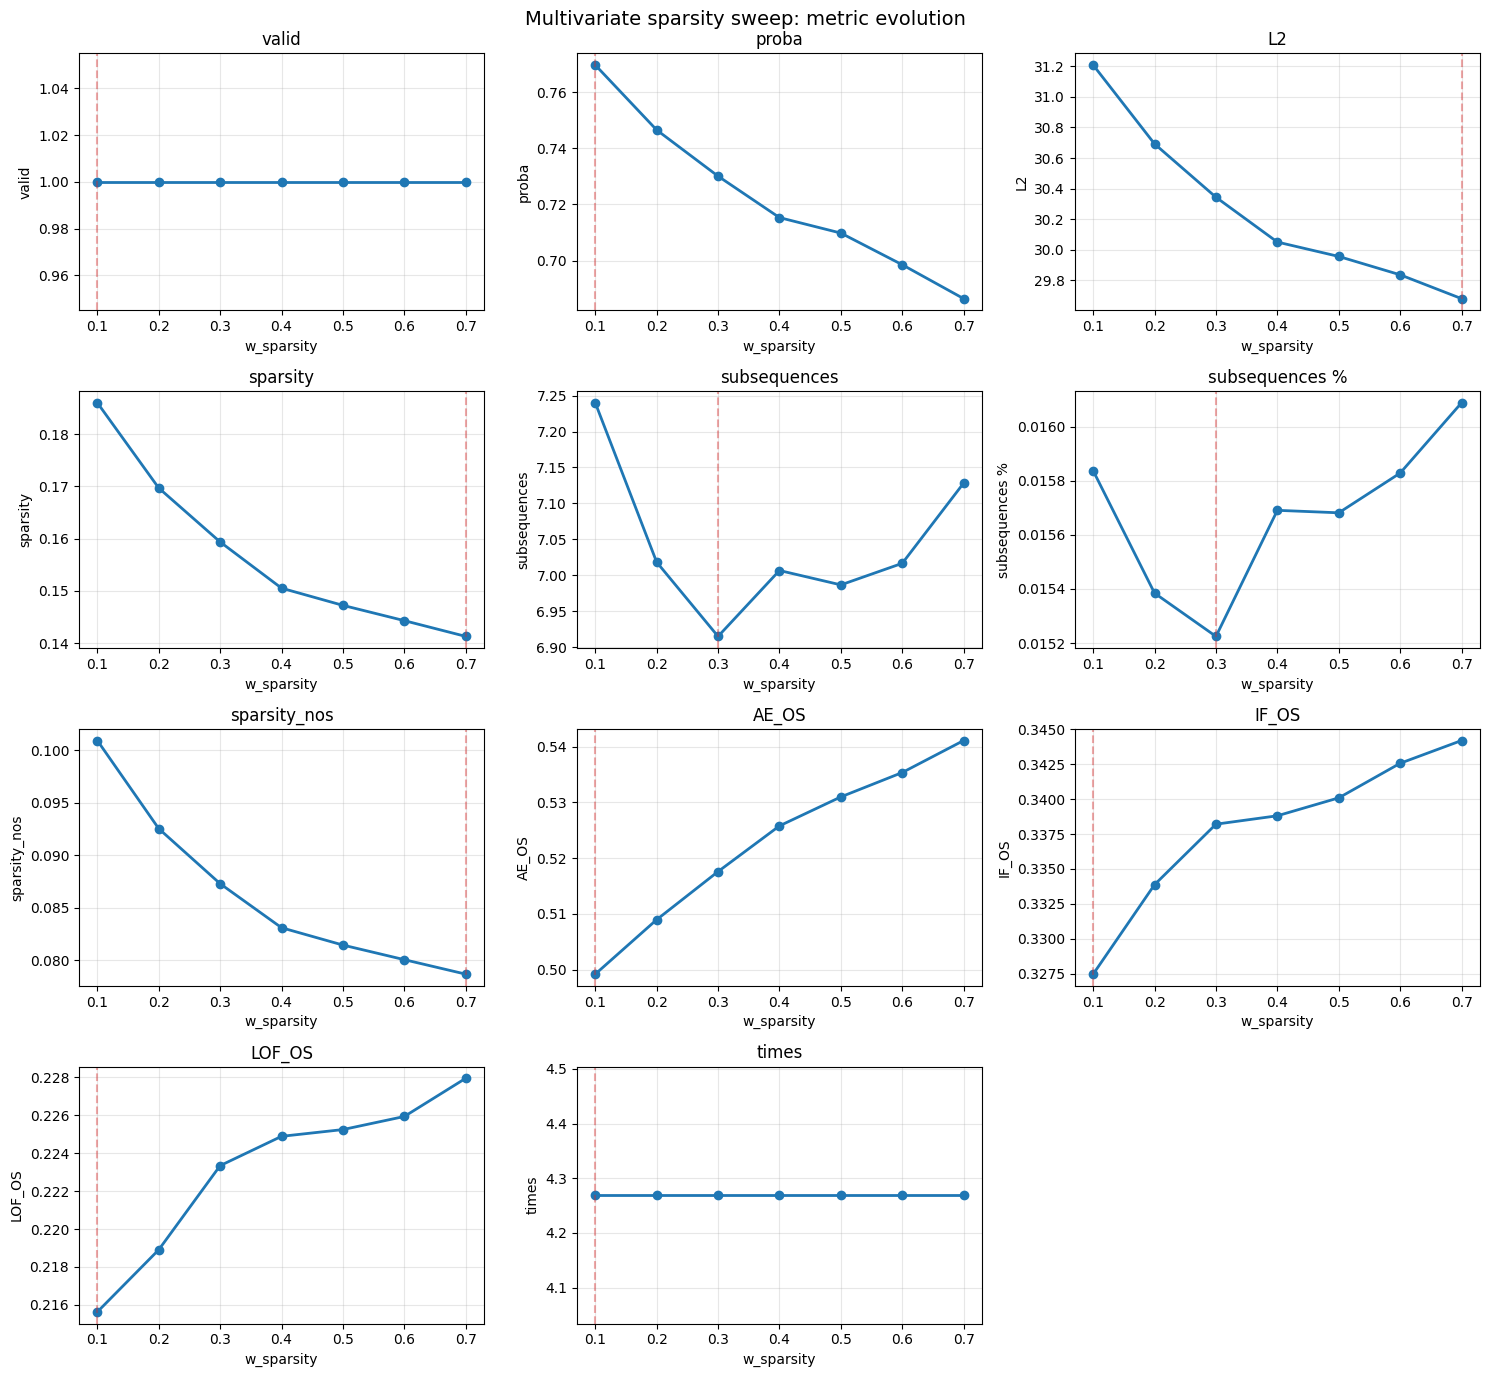

In [33]:
plot_metric_evolution(sparsity_profile_metrics_multi, 'Multivariate sparsity sweep: metric evolution')


In [ ]:
sparsity_results_uni, sparsity_ranks_uni = evaluate_multispace_grid(
    sparsity_weights_df,
    default_results_uni,
    UNIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'univariate',
    univariate_contexts,
)
sparsity_dataset_metrics_uni, sparsity_profile_metrics_uni = compute_profile_metric_summary(sparsity_results_uni)


In [ ]:
print('Univariate sparsity sweep: average ranks')
display(extract_multispace_rank_rows(sparsity_ranks_uni))


In [ ]:
print('Univariate sparsity sweep: direct metric values')
display(extract_multispace_metric_rows(sparsity_profile_metrics_uni))


In [ ]:
plot_metric_evolution(sparsity_profile_metrics_uni, 'Univariate sparsity sweep: metric evolution')


## Contiguity-weight sweep


In [12]:
contiguity_results_multi, contiguity_ranks_multi = evaluate_multispace_grid(
    contiguity_weights_df,
    default_results_multi,
    MULTIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'multivariate',
    multivariate_contexts,
)
contiguity_dataset_metrics_multi, contiguity_profile_metrics_multi = compute_profile_metric_summary(contiguity_results_multi)


Evaluating multivariate:   0%|          | 0/3 [00:00<?, ?it/s]

ec57e0a613241455487f3f40483cd34095c81bf7



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:05<00:00,  7.70it/s]


Common test indexes are 40: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  7.02it/s]


...

Common test indexes are 40: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  7.14it/s]


Common test indexes are 100: [0, 1, 2, 5, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 26, 29, 30, 31, 35, 36, 37, 38, 40, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 57, 58, 59, 61, 62, 64, 66, 69, 72, 76, 77, 78, 79, 81, 83, 84, 88, 89, 91, 92, 93, 95, 99, 101, 102, 103, 104, 108, 109, 111, 112, 113, 114, 116, 117, 122, 124, 125, 126, 136, 138, 140, 141, 144, 148, 150, 151, 152, 154, 155, 156, 158, 160, 163, 164, 165, 168, 169, 170, 171, 173, 175, 177, 178, 179]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  7.04it/s]


Common test indexes are 100: [3, 13, 14, 15, 19, 22, 23, 25, 29, 31, 32, 44, 47, 51, 54, 61, 64, 65, 70, 72, 76, 79, 82, 84, 88, 90, 100, 104, 105, 108, 109, 111, 113, 114, 115, 119, 121, 124, 125, 126, 127, 128, 131, 135, 136, 139, 147, 152, 154, 155, 157, 158, 161, 162, 165, 169, 172, 175, 177, 178, 185, 197, 201, 202, 203, 205, 211, 213, 215, 218, 219, 220, 224, 225, 226, 237, 238, 239, 240, 241, 243, 245, 255, 261, 262, 265, 266, 268, 273, 282, 284, 291, 292, 293, 299, 300, 302, 303, 314, 318]


In [13]:
print('Multivariate contiguity sweep: average ranks')
display(extract_multispace_rank_rows(contiguity_ranks_multi))


Multivariate contiguity sweep: average ranks


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,valid,proba,L2,sparsity,subsequences,subsequences %,sparsity_nos,AE_OS,IF_OS,LOF_OS,AE_IOS,IF_IOS,LOF_IOS,times
0,contiguity_0.1,contiguity,0.1,0.48,0.1,0.32,1.0,2.333333,3.0,3.333333,2.0,2.0,2.666667,1.333333,2.000000,2.333333,1.000000,1.333333,2.0,2.0
1,contiguity_0.2,contiguity,0.1,0.42,0.2,0.28,1.0,2.333333,3.0,3.333333,2.0,2.0,2.666667,1.333333,2.000000,2.333333,1.000000,1.333333,2.0,2.0
2,contiguity_0.3,contiguity,0.1,0.36,0.3,0.24,1.0,2.333333,3.0,3.333333,2.0,2.0,2.666667,1.333333,2.000000,2.333333,1.000000,1.333333,2.0,2.0
3,contiguity_0.4,contiguity,0.1,0.30,0.4,0.20,1.0,2.333333,3.0,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.000000,1.666667,2.0,2.0
4,contiguity_0.5,contiguity,0.1,0.24,0.5,0.16,1.0,2.333333,3.0,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.333333,1.666667,2.0,2.0
5,contiguity_0.6,contiguity,0.1,0.18,0.6,0.12,1.0,2.333333,3.0,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.333333,1.666667,2.0,2.0
6,contiguity_0.7,contiguity,0.1,0.12,0.7,0.08,1.0,2.333333,3.0,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.333333,1.666667,2.0,2.0


In [14]:
print('Multivariate contiguity sweep: direct metric values')
display(extract_multispace_metric_rows(contiguity_profile_metrics_multi))


Multivariate contiguity sweep: direct metric values


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,valid,proba,L2,sparsity,subsequences,subsequences %,sparsity_nos,AE_OS,IF_OS,LOF_OS,AE_IOS,IF_IOS,LOF_IOS,times
0,contiguity_0.1,contiguity,0.1,0.48,0.1,0.32,1.0,0.728506,30.166518,0.156982,7.588333,0.016739,0.086861,0.513149,0.337389,0.220286,0.055286,0.021811,0.022517,4.269282
1,contiguity_0.2,contiguity,0.1,0.42,0.2,0.28,1.0,0.727995,30.177341,0.155812,7.295000,0.016250,0.086031,0.515973,0.338315,0.220813,0.058140,0.022811,0.022535,4.269282
2,contiguity_0.3,contiguity,0.1,0.36,0.3,0.24,1.0,0.730599,30.213755,0.156908,7.150000,0.015905,0.086406,0.516587,0.337743,0.220646,0.059636,0.022622,0.022393,4.269282
3,contiguity_0.4,contiguity,0.1,0.30,0.4,0.20,1.0,0.730093,30.343981,0.159359,6.915000,0.015225,0.087292,0.517577,0.338203,0.223342,0.061307,0.023368,0.025104,4.269282
4,contiguity_0.5,contiguity,0.1,0.24,0.5,0.16,1.0,0.741710,30.582209,0.164301,6.886667,0.015136,0.089718,0.515781,0.336652,0.221451,0.062321,0.023577,0.025022,4.269282
5,contiguity_0.6,contiguity,0.1,0.18,0.6,0.12,1.0,0.745592,30.742415,0.167157,6.748333,0.014929,0.091043,0.517673,0.334301,0.220999,0.065634,0.023879,0.024940,4.269282
6,contiguity_0.7,contiguity,0.1,0.12,0.7,0.08,1.0,0.749733,30.805832,0.168530,6.730000,0.014888,0.091709,0.520835,0.335189,0.221463,0.069751,0.024094,0.025258,4.269282


In [ ]:
plot_metric_evolution(contiguity_profile_metrics_multi, 'Multivariate contiguity sweep: metric evolution')


In [ ]:
contiguity_results_uni, contiguity_ranks_uni = evaluate_multispace_grid(
    contiguity_weights_df,
    default_results_uni,
    UNIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'univariate',
    univariate_contexts,
)
contiguity_dataset_metrics_uni, contiguity_profile_metrics_uni = compute_profile_metric_summary(contiguity_results_uni)


In [ ]:
print('Univariate contiguity sweep: average ranks')
display(extract_multispace_rank_rows(contiguity_ranks_uni))


In [ ]:
print('Univariate contiguity sweep: direct metric values')
display(extract_multispace_metric_rows(contiguity_profile_metrics_uni))


In [ ]:
plot_metric_evolution(contiguity_profile_metrics_uni, 'Univariate contiguity sweep: metric evolution')


## Plausibility-weight sweep


In [15]:
plausibility_results_multi, plausibility_ranks_multi = evaluate_multispace_grid(
    plausibility_weights_df,
    default_results_multi,
    MULTIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'multivariate',
    multivariate_contexts,
)
plausibility_dataset_metrics_multi, plausibility_profile_metrics_multi = compute_profile_metric_summary(plausibility_results_multi)


Evaluating multivariate:   0%|          | 0/3 [00:00<?, ?it/s]

ec57e0a613241455487f3f40483cd34095c81bf7



100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 40/40 [00:06<00:00,  6.48it/s]


Common test indexes are 40: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.23it/s]


...

Common test indexes are 40: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:13<00:00,  7.31it/s]


Common test indexes are 100: [0, 1, 2, 5, 9, 11, 13, 14, 15, 16, 17, 19, 20, 21, 22, 25, 26, 29, 30, 31, 35, 36, 37, 38, 40, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 57, 58, 59, 61, 62, 64, 66, 69, 72, 76, 77, 78, 79, 81, 83, 84, 88, 89, 91, 92, 93, 95, 99, 101, 102, 103, 104, 108, 109, 111, 112, 113, 114, 116, 117, 122, 124, 125, 126, 136, 138, 140, 141, 144, 148, 150, 151, 152, 154, 155, 156, 158, 160, 163, 164, 165, 168, 169, 170, 171, 173, 175, 177, 178, 179]
ec57e0a613241455487f3f40483cd34095c81bf7



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:14<00:00,  7.10it/s]


Common test indexes are 100: [3, 13, 14, 15, 19, 22, 23, 25, 29, 31, 32, 44, 47, 51, 54, 61, 64, 65, 70, 72, 76, 79, 82, 84, 88, 90, 100, 104, 105, 108, 109, 111, 113, 114, 115, 119, 121, 124, 125, 126, 127, 128, 131, 135, 136, 139, 147, 152, 154, 155, 157, 158, 161, 162, 165, 169, 172, 175, 177, 178, 185, 197, 201, 202, 203, 205, 211, 213, 215, 218, 219, 220, 224, 225, 226, 237, 238, 239, 240, 241, 243, 245, 255, 261, 262, 265, 266, 268, 273, 282, 284, 291, 292, 293, 299, 300, 302, 303, 314, 318]


In [16]:
print('Multivariate plausibility sweep: average ranks')
display(extract_multispace_rank_rows(plausibility_ranks_multi))


Multivariate plausibility sweep: average ranks


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,valid,proba,L2,sparsity,subsequences,subsequences %,sparsity_nos,AE_OS,IF_OS,LOF_OS,AE_IOS,IF_IOS,LOF_IOS,times
0,plausibility_0.1,plausibility,0.1,0.342857,0.457143,0.1,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.333333,1.333333,2.0,2.0
1,plausibility_0.2,plausibility,0.1,0.300000,0.400000,0.2,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.000000,1.666667,2.0,2.0
2,plausibility_0.3,plausibility,0.1,0.257143,0.342857,0.3,1.0,2.333333,3.000000,3.333333,2.0,2.0,2.666667,1.333333,2.333333,2.333333,1.000000,1.333333,2.0,2.0
3,plausibility_0.4,plausibility,0.1,0.214286,0.285714,0.4,1.0,2.000000,3.000000,3.333333,2.0,2.0,2.666667,1.000000,2.000000,2.333333,1.000000,1.333333,2.0,2.0
4,plausibility_0.5,plausibility,0.1,0.171429,0.228571,0.5,1.0,2.000000,3.000000,3.666667,2.0,2.0,2.666667,1.000000,1.666667,2.333333,1.000000,1.666667,2.0,2.0
5,plausibility_0.6,plausibility,0.1,0.128571,0.171429,0.6,1.0,2.000000,3.000000,3.666667,2.0,2.0,2.666667,1.000000,1.666667,2.333333,1.000000,1.666667,2.0,2.0
6,plausibility_0.7,plausibility,0.1,0.085714,0.114286,0.7,1.0,1.666667,3.333333,4.000000,2.0,2.0,3.666667,1.000000,1.333333,2.333333,1.000000,1.333333,2.0,2.0


In [17]:
print('Multivariate plausibility sweep: direct metric values')
display(extract_multispace_metric_rows(plausibility_profile_metrics_multi))


Multivariate plausibility sweep: direct metric values


,profile,sweep,w_adv,w_sparsity,w_contiguity,w_plausibility,valid,proba,L2,sparsity,subsequences,subsequences %,sparsity_nos,AE_OS,IF_OS,LOF_OS,AE_IOS,IF_IOS,LOF_IOS,times
0,plausibility_0.1,plausibility,0.1,0.342857,0.457143,0.1,1.0,0.714576,30.121291,0.152004,6.640000,0.014720,0.083362,0.530841,0.340899,0.225719,0.073849,0.022910,0.024702,4.269282
1,plausibility_0.2,plausibility,0.1,0.300000,0.400000,0.2,1.0,0.730093,30.343981,0.159359,6.915000,0.015225,0.087292,0.517577,0.338203,0.223342,0.061307,0.023368,0.025104,4.269282
2,plausibility_0.3,plausibility,0.1,0.257143,0.342857,0.3,1.0,0.741026,30.481396,0.165971,7.145000,0.015655,0.090813,0.509789,0.336204,0.219086,0.053766,0.022926,0.022883,4.269282
3,plausibility_0.4,plausibility,0.1,0.214286,0.285714,0.4,1.0,0.760975,31.037845,0.181283,7.878333,0.016981,0.099132,0.495264,0.331498,0.215278,0.043399,0.022720,0.023415,4.269282
4,plausibility_0.5,plausibility,0.1,0.171429,0.228571,0.5,1.0,0.781670,31.475923,0.195972,8.650000,0.018584,0.107278,0.485551,0.325782,0.211906,0.037698,0.023614,0.023842,4.269282
5,plausibility_0.6,plausibility,0.1,0.128571,0.171429,0.6,1.0,0.801434,32.041884,0.210094,9.240000,0.019971,0.115033,0.478324,0.320097,0.209111,0.035521,0.023651,0.022474,4.269282
6,plausibility_0.7,plausibility,0.1,0.085714,0.114286,0.7,1.0,0.823165,32.726638,0.228788,10.116667,0.021992,0.125390,0.472108,0.312951,0.203293,0.033484,0.022702,0.020217,4.269282


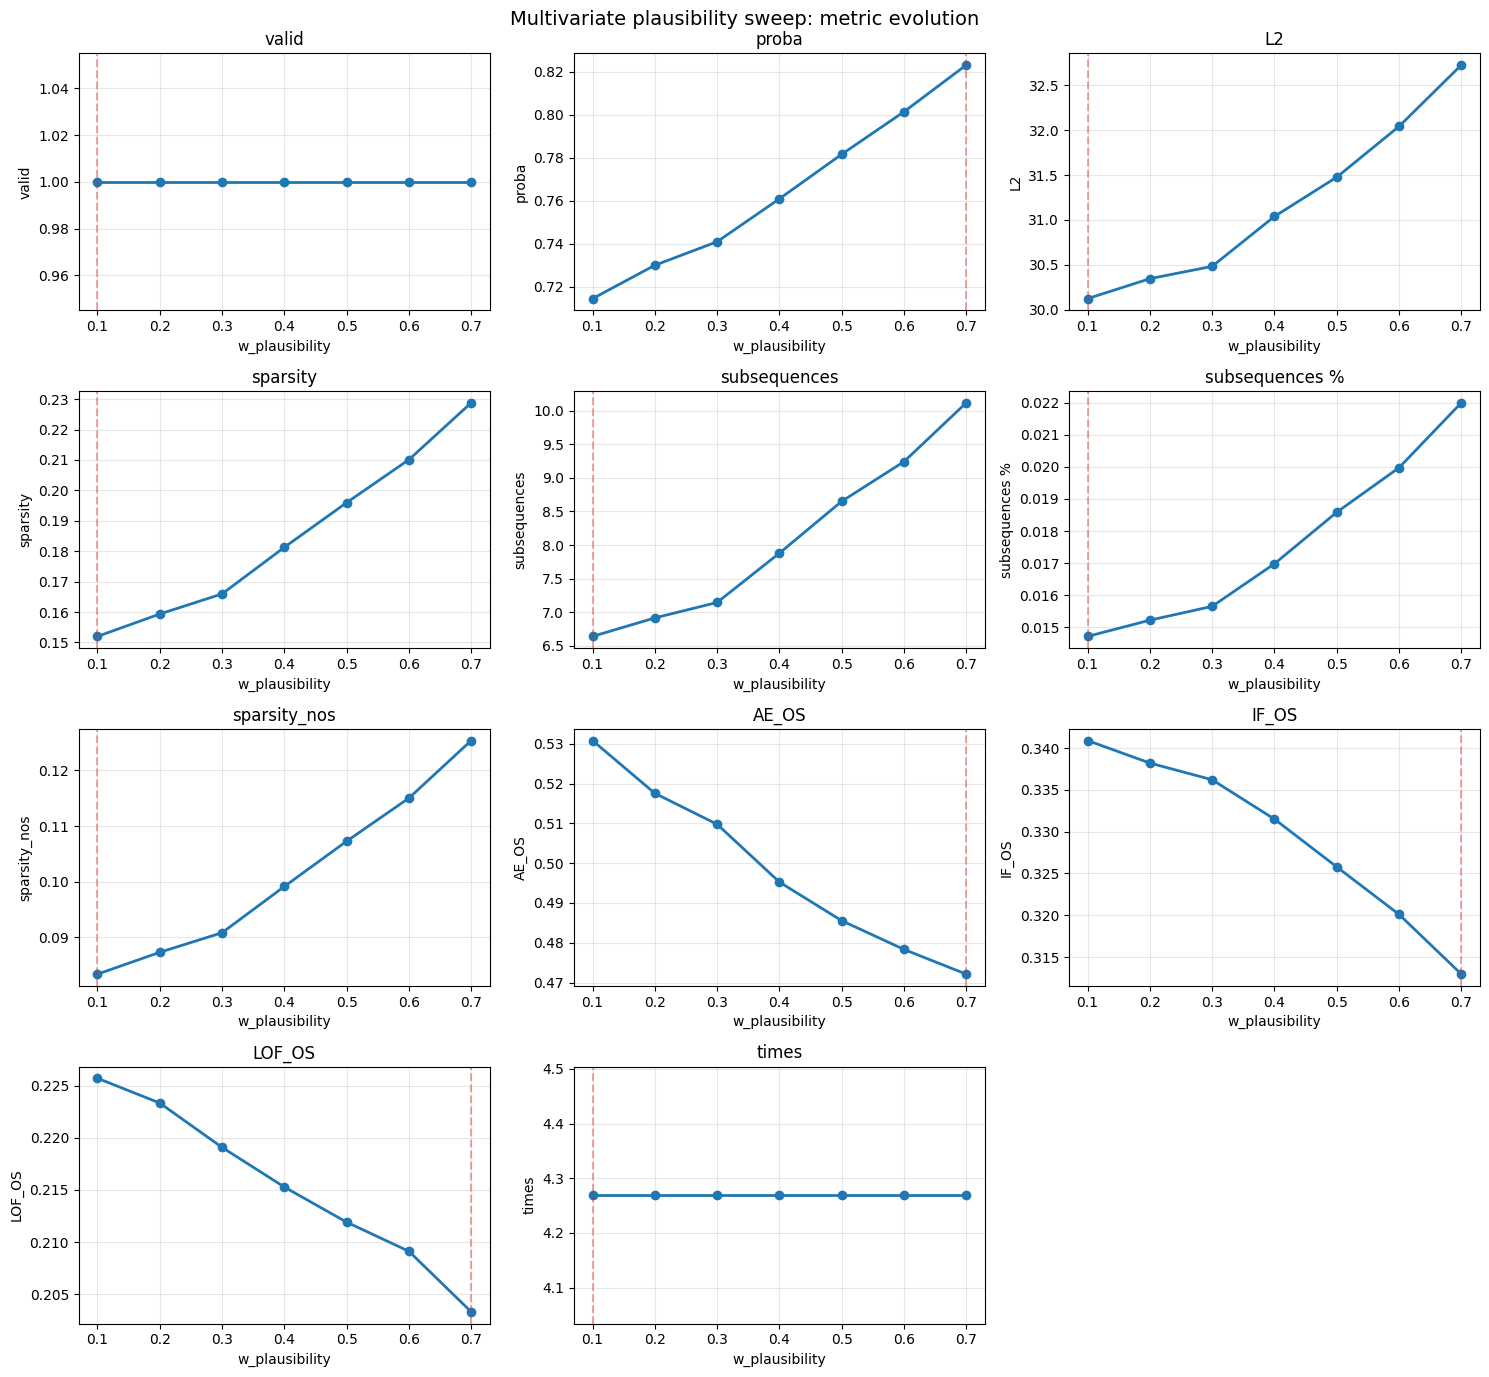

In [18]:
plot_metric_evolution(plausibility_profile_metrics_multi, 'Multivariate plausibility sweep: metric evolution')


In [ ]:
plausibility_results_uni, plausibility_ranks_uni = evaluate_multispace_grid(
    plausibility_weights_df,
    default_results_uni,
    UNIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'univariate',
    univariate_contexts,
)
plausibility_dataset_metrics_uni, plausibility_profile_metrics_uni = compute_profile_metric_summary(plausibility_results_uni)


In [ ]:
print('Univariate plausibility sweep: average ranks')
display(extract_multispace_rank_rows(plausibility_ranks_uni))


In [ ]:
print('Univariate plausibility sweep: direct metric values')
display(extract_multispace_metric_rows(plausibility_profile_metrics_uni))


In [ ]:
plot_metric_evolution(plausibility_profile_metrics_uni, 'Univariate plausibility sweep: metric evolution')


## Stability summary


In [21]:
all_sweep_ranks_multi = pd.concat(
    [sparsity_ranks_multi, contiguity_ranks_multi, plausibility_ranks_multi],
    ignore_index=True,
)
stability_summary_multi = build_stability_summary(default_ranks_multi, all_sweep_ranks_multi, 'multivariate')
print('Multivariate stability summary')
display(stability_summary_multi)

Multivariate stability summary


,setting,metric,default_rank,min_rank,max_rank,mean_rank,std_rank
0,multivariate,valid,1.000000,1.000000,1.000000,1.000000,0.000000e+00
1,multivariate,proba,2.333333,1.666667,2.333333,2.253968,1.753232e-01
2,multivariate,L2,3.000000,2.666667,3.333333,3.000000,1.028689e-01
3,multivariate,sparsity,3.333333,3.333333,4.000000,3.396825,1.664776e-01
4,multivariate,subsequences,2.000000,2.000000,2.000000,2.000000,0.000000e+00
5,multivariate,subsequences %,2.000000,2.000000,2.000000,2.000000,0.000000e+00
6,multivariate,sparsity_nos,2.666667,2.666667,3.666667,2.714286,2.129589e-01
7,multivariate,AE_OS,1.333333,1.000000,1.333333,1.269841,1.308922e-01
8,multivariate,IF_OS,2.333333,1.333333,2.333333,2.095238,2.749287e-01
9,multivariate,LOF_OS,2.333333,2.333333,2.333333,2.333333,4.440892e-16


In [ ]:
all_sweep_ranks_uni = pd.concat(
    [sparsity_ranks_uni, contiguity_ranks_uni, plausibility_ranks_uni],
    ignore_index=True,
)
stability_summary_uni = build_stability_summary(default_ranks_uni, all_sweep_ranks_uni, 'univariate')
print('Univariate stability summary')
display(stability_summary_uni)

## Optional balanced profile


In [ ]:
balanced_weights_df = pd.DataFrame([
    {
        'profile': 'balanced_0.25_each',
        'sweep': 'balanced',
        'w_adv': 0.25,
        'w_sparsity': 0.25,
        'w_contiguity': 0.25,
        'w_plausibility': 0.25,
        'weights': BALANCED_PROFILE.tolist(),
    }
])

balanced_results_multi, balanced_ranks_multi = evaluate_multispace_grid(
    balanced_weights_df,
    default_results_multi,
    MULTIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'multivariate',
    multivariate_contexts,
)
balanced_results_uni, balanced_ranks_uni = evaluate_multispace_grid(
    balanced_weights_df,
    default_results_uni,
    UNIVARIATE_DATASETS,
    MULTISPACE_METHOD,
    MODEL_TO_EXPLAIN,
    'univariate',
    univariate_contexts,
)

_, balanced_profile_metrics_multi = compute_profile_metric_summary(balanced_results_multi)
_, balanced_profile_metrics_uni = compute_profile_metric_summary(balanced_results_uni)


In [ ]:
print('Balanced profile ranks: multivariate')
display(extract_multispace_rank_rows(balanced_ranks_multi))
print('Balanced profile metric values: multivariate')
display(extract_multispace_metric_rows(balanced_profile_metrics_multi))
print('Balanced profile ranks: univariate')
display(extract_multispace_rank_rows(balanced_ranks_uni))
print('Balanced profile metric values: univariate')
display(extract_multispace_metric_rows(balanced_profile_metrics_uni))


## Diagnostics


In [ ]:
all_profile_results = pd.concat(
    [
        add_default_profile_metadata(default_results_multi, 'multivariate'),
        add_default_profile_metadata(default_results_uni, 'univariate'),
        sparsity_results_multi,
        sparsity_results_uni,
        contiguity_results_multi,
        contiguity_results_uni,
        plausibility_results_multi,
        plausibility_results_uni,
        balanced_results_multi,
        balanced_results_uni,
    ],
    ignore_index=True,
)

multispace_diagnostics = (
    all_profile_results.loc[all_profile_results['method'] == MULTISPACE_NAME]
    .groupby(
        [
            'setting',
            'sweep',
            'profile',
            'w_adv',
            'w_sparsity',
            'w_contiguity',
            'w_plausibility',
        ],
        as_index=False,
    )
    .agg(
        validity=('valid', 'mean'),
        n_instances=('valid', 'size'),
        n_datasets=('dataset', 'nunique'),
    )
)

profile_counts = summarize_counts(all_profile_results, ['setting', 'profile', 'dataset', 'method'])


In [ ]:
print('Multi-SpaCE validity diagnostics across profiles')
display(multispace_diagnostics)
if (multispace_diagnostics['validity'] < 0.999).any():
    print('Warning: at least one Multi-SpaCE profile has validity below 0.999.')
else:
    print('Validity check passed: all Multi-SpaCE profiles are at or very near 1.0.')

print('Evaluated instance counts per method, dataset, and profile')
display(profile_counts)
